# Replication of reskilling analysis from MSc thesis
Felix Zaussinger | 15.09.2022

**Core Analysis Goal(s)**
1. Replicate thesis approach based on updated data
2. Decide how to deal with skewed distribution when working with COOC matrix compared to ESCO matrix tables or Kanders Matrix
3. Understand and write down all of the assumptions that I make and reflect whether they are robust enough

**Key Insight(s)**
1. Replication based on ESCO v.1.1 is working!
2.
3.

In [1]:
import os
import scipy
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

from tqdm import tqdm
from mapping_career_causeways.compare_nodes_utils import find_closest

import seaborn as sns
import matplotlib.pyplot as plt

# load paths
from src import utils
from src.data.lfs import EuLfs
from src.modelling.reskilling import ReskillingPathways
from src.data.framework import Esco

useful_paths = utils.UsefulPaths()

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
pd.options.display.float_format = "{:,.2f}".format

sns.set_context("paper", font_scale=1.5, rc={"figure.dpi": 72})
sns.set_style("ticks")

#### Load data

##### Auxillary data

In [2]:
# Read geodata with NUTS regions
gdf = gpd.read_file(
    os.path.join(
        useful_paths.data_raw,
        "geodata",
        "NUTS_RG_03M_2021_4326_LEVL_2",
        "NUTS_RG_03M_2021_4326_LEVL_2.shp",
    )
)

##### LFS data

In [3]:
# esco data
esco = Esco()

# EU-LFS data
config = utils.load_config(os.path.join(useful_paths.config_dir, "eu_lfs_config.yml"))
lfs = EuLfs(config=config)
year = 2019

lfs_data = lfs.read_preprocessed_file(
    year=year,
    input_fname_lfs="eu_lfs_merged_{year}_with_final_unweighted_shares_and_earnings_incdecil_imputed",
)

##### Impute REGIONW variable
- when REGIONW is not available but REGION is, impute REGIONW with REGION
- otherwise, impute REGIONW and REGION with "99", a placeholder for "only country code available"
- reassign NUTS code on this basis

In [4]:
# add required categories
cats_regionw = lfs_data["REGIONW"].cat.categories.values
cats_region = lfs_data["REGION"].cat.categories.values

placeholder_cat = "99"

new_cats_regionw = list(set(cats_region) - set(cats_regionw))
new_cats_region = list(set(cats_regionw) - set(cats_region))

new_cats_regionw.append(placeholder_cat)
new_cats_region.append(placeholder_cat)

lfs_data["REGIONW"] = lfs_data["REGIONW"].cat.add_categories(new_cats_regionw)
lfs_data["REGION"] = lfs_data["REGION"].cat.add_categories(new_cats_region)

# fill nans in regionw with region
lfs_data["REGIONW"] = lfs_data["REGIONW"].fillna(lfs_data["REGION"])

# fill remaining nans with placeholder
lfs_data["REGIONW"] = lfs_data["REGIONW"].fillna("99")
lfs_data["REGION"] = lfs_data["REGION"].fillna("99")

# update nuts id
lfs_data["NUTS_ID"] = lfs_data["COUNTRYW"].astype("string") + lfs_data[
    "REGIONW"
].astype("string")

#### Initialise reskilling simulation

In [5]:
# reskilling simulations
osm_version = "weighted"
sim_metric = "cooc"
diagonal_zeros = False

rp = ReskillingPathways(
    osm_version=osm_version, sim_metric=sim_metric, lfs_data=lfs_data, year=year
)

In [6]:
df_occs = rp.get_occs()

#### Computing occupation similarity at ISCO-3D level

Notes
- occupation distance measure at ISCO 3D level (todo: aggregate from ESCO)
- additional covariates: income deciles, skill level as proxy for education, ...
- analysis will be slightly different than the Nesta approach

Questions
- calculate average skill profile of 3D groups is calculated from occ-skills matrix (not possible for Kanders matrix as I miss the input data)

Decision
- use self-calculated, weighted occ-skills matrix
- compute avg skills profiles at ISCO 3D level

In [7]:
# read occ sim matrix
df_occ_sims = rp.sim_matrix_at_level(level="isco_3_digit", mask_diagonal=True)

# create numpy matrix and fill diagonal with zeros (avoid self-transitions)
similarity_matrix = df_occ_sims.copy().values
# np.fill_diagonal(similarity_matrix, 0)

#### Calibrate transition thresholds

##### Calculate within-group occupation similarities for different granularity levels

In [8]:
df_occ_sim = rp.df_occ_sim
df_sim_container = rp.calc_sim_means_by_level()
df_sim_container.to_csv(
    os.path.join(
        useful_paths.figure_dir,
        "esco",
        "transition_threshold_calibration_stats_by_group_and_level.csv",
    )
)

In [9]:
df_sim_container

,level,occupation,sim_mean,sim_sd,n
0,esco_5_digit,2654.1,6.03,6.90,9.00
1,esco_5_digit,8121.4,21.00,0.00,1.00
2,esco_5_digit,7543.1,4.42,7.64,7.00
3,esco_5_digit,3155.1,21.00,0.00,1.00
4,esco_5_digit,2431.9,20.75,0.00,1.00
...,...,...,...,...,...
2071,isco_3_digit,221,21.81,6.90,2.00
2072,isco_3_digit,941,9.92,5.51,4.00
2073,isco_3_digit,952,28.50,0.00,1.00
2074,isco_3_digit,521,16.25,3.75,2.00


##### Overview graphic of skill overlap requirement calibration

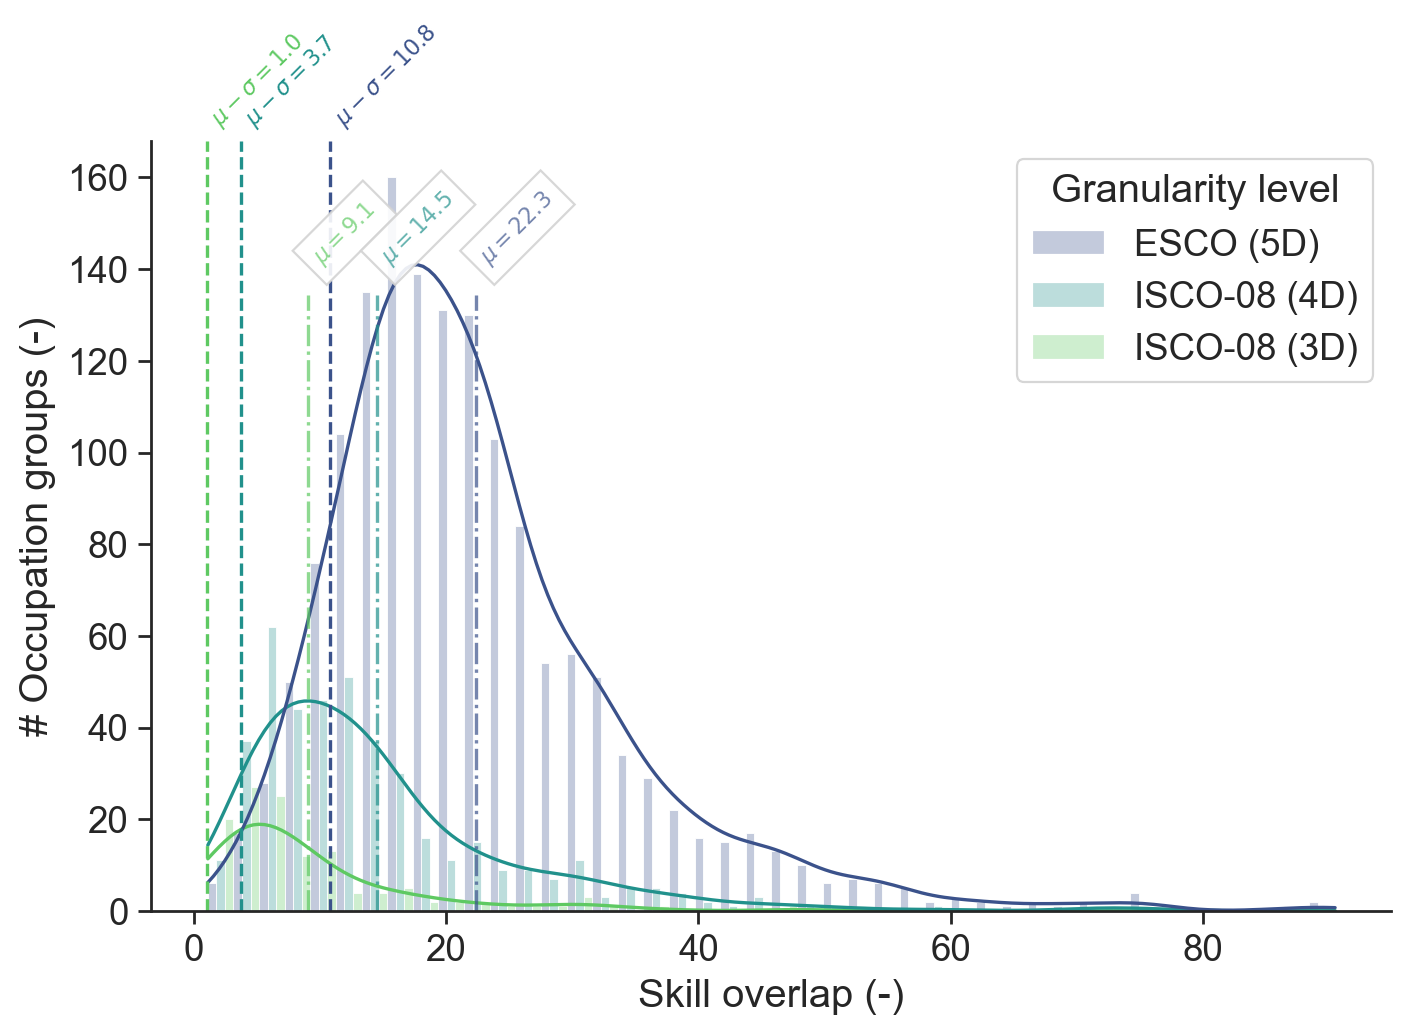

In [10]:
x = "sim_mean"

rename_dict = {
    "esco_5_digit": "ESCO (5D)",
    "isco_4_digit": "ISCO-08 (4D)",
    "isco_3_digit": "ISCO-08 (3D)",
}
lvl_name = "Granularity level"
multiple = "dodge"
kde_kws = dict(
    bw_adjust=1
)  # bandwidth, or standard deviation of the smoothing kernel. curve is normalized so that the integral over all possible values is 1.
hue_order = ["ESCO (5D)", "ISCO-08 (4D)", "ISCO-08 (3D)"]

plotting_data = df_sim_container.replace(to_replace={"level": rename_dict}).rename(
    columns={"level": lvl_name}
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=plotting_data,
    x=x,
    hue=lvl_name,
    hue_order=hue_order,
    multiple=multiple,
    kde=True,
    kde_kws=kde_kws,
    alpha=0.3,
    palette="viridis",
    common_bins=True,
    common_norm=True,
    ax=ax,
)

# annotate means
for container, hue in zip(ax.containers, hue_order[::-1]):

    # calc group-level statistics
    distr_mean = plotting_data.loc[plotting_data[lvl_name] == hue, x].mean()
    distr_sd = plotting_data.loc[plotting_data[lvl_name] == hue, x].std()
    thresh = distr_mean - distr_sd

    # params
    rotation = 45
    va = "bottom"
    ha = "left"
    fontsize = 8
    color = container[-1].get_facecolor()

    # annotate treshholds
    alpha = 1
    ymax = 170
    ax.axvline(
        x=thresh,
        ymax=1,
        linestyle="--",
        color=color,
        label=r"$\mu - \sigma$",
        alpha=alpha,
    )  # , zorder=0)

    ax.text(
        x=thresh,
        y=ymax,
        s="$\mu - \sigma = {:.1f}$".format(thresh),
        rotation=rotation,
        va=va,
        ha=ha,
        fontsize=fontsize,
        color=color,
        alpha=alpha,
    )

    # annotate means
    alpha = 0.7
    ymax = 140
    ax.axvline(
        x=distr_mean,
        ymin=0,
        ymax=0.8,
        linestyle="-.",
        color=color,
        label=r"$\mu",
        alpha=alpha,
    )  # , zorder=0)

    ax.text(
        x=distr_mean,
        y=ymax,
        s="$\mu = {:.1f}$".format(distr_mean),
        rotation=rotation,
        va=va,
        ha=ha,
        fontsize=fontsize,
        color=color,
        alpha=alpha,
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="lightgrey"),
    )

# style
# ax.set_xlim(0)
ax.set_xlabel("Skill overlap (-)")
ax.set_ylabel("# Occupation groups (-)")
sns.despine()

# save
plt.savefig(
    os.path.join(
        useful_paths.figure_dir, "esco", "transition_threshold_calibration_overview.png"
    ),
    dpi=300,
    bbox_inches="tight",
)

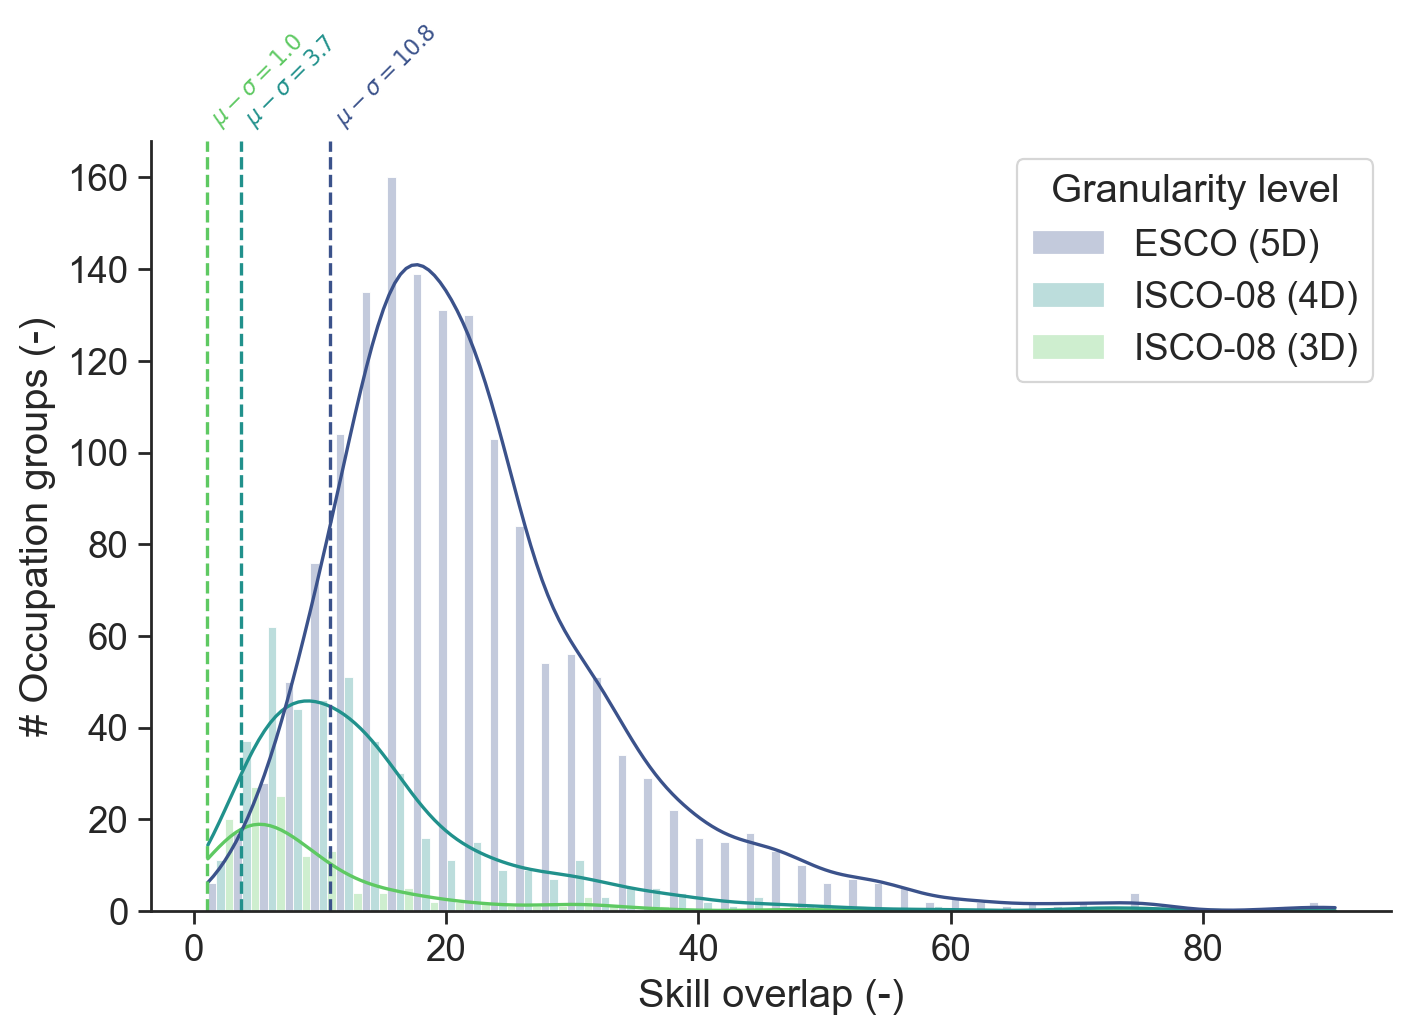

In [11]:
x = "sim_mean"

rename_dict = {
    "esco_5_digit": "ESCO (5D)",
    "isco_4_digit": "ISCO-08 (4D)",
    "isco_3_digit": "ISCO-08 (3D)",
}
lvl_name = "Granularity level"
multiple = "dodge"
kde_kws = dict(
    bw_adjust=1
)  # bandwidth, or standard deviation of the smoothing kernel. curve is normalized so that the integral over all possible values is 1.
hue_order = ["ESCO (5D)", "ISCO-08 (4D)", "ISCO-08 (3D)"]

plotting_data = df_sim_container.replace(to_replace={"level": rename_dict}).rename(
    columns={"level": lvl_name}
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=plotting_data,
    x=x,
    hue=lvl_name,
    hue_order=hue_order,
    multiple=multiple,
    kde=True,
    kde_kws=kde_kws,
    alpha=0.3,
    palette="viridis",
    common_bins=True,
    common_norm=True,
    ax=ax,
)

# annotate means
for container, hue in zip(ax.containers, hue_order[::-1]):

    # calc group-level statistics
    distr_mean = plotting_data.loc[plotting_data[lvl_name] == hue, x].mean()
    distr_sd = plotting_data.loc[plotting_data[lvl_name] == hue, x].std()
    thresh = distr_mean - distr_sd

    # params
    rotation = 45
    va = "bottom"
    ha = "left"
    fontsize = 8
    color = container[-1].get_facecolor()

    # annotate treshholds
    alpha = 1
    ymax = 170
    ax.axvline(
        x=thresh,
        ymax=1,
        linestyle="--",
        color=color,
        label=r"$\mu - \sigma$",
        alpha=alpha,
    )  # , zorder=0)

    ax.text(
        x=thresh,
        y=ymax,
        s="$\mu - \sigma = {:.1f}$".format(thresh),
        rotation=rotation,
        va=va,
        ha=ha,
        fontsize=fontsize,
        color=color,
        alpha=alpha,
    )

# style
# ax.set_xlim(0)
ax.set_xlabel("Skill overlap (-)")
ax.set_ylabel("# Occupation groups (-)")
sns.despine()

# save
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "esco",
        "transition_threshold_calibration_overview_reduced.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Plot results

In [12]:
rp.transition_thresholds = rp.calc_transition_thresholds(show_plots=False)
rp.transition_thresholds.to_csv(
    os.path.join(
        useful_paths.figure_dir, "esco", "transition_threshold_calibration.csv"
    )
)
rp.transition_thresholds

,mean,sd,mean-sd,mean+sd,threshold_category
esco_5_digit,22.35,11.55,10.80,33.90,viable_high
isco_4_digit,14.47,10.79,3.68,25.26,viable
isco_3_digit,9.06,8.06,1.00,17.12,viable_low


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [13]:
rp.trans_thresh_pc_approach

array([2.25, 7.5 ])

In [14]:
np.percentile(
    rp.df_occ_sim.values.flatten(), q=(90, 96, 97.5, 99)
)

array([1.  , 2.25, 3.5 , 7.5 ])

##### Percentiles of overall distribution
1.616368047779022 6.500853535353546

In [15]:
q_viable, q_highly_viable = rp.trans_thresh_pc_approach
print(q_viable, q_highly_viable)

2.25 7.5


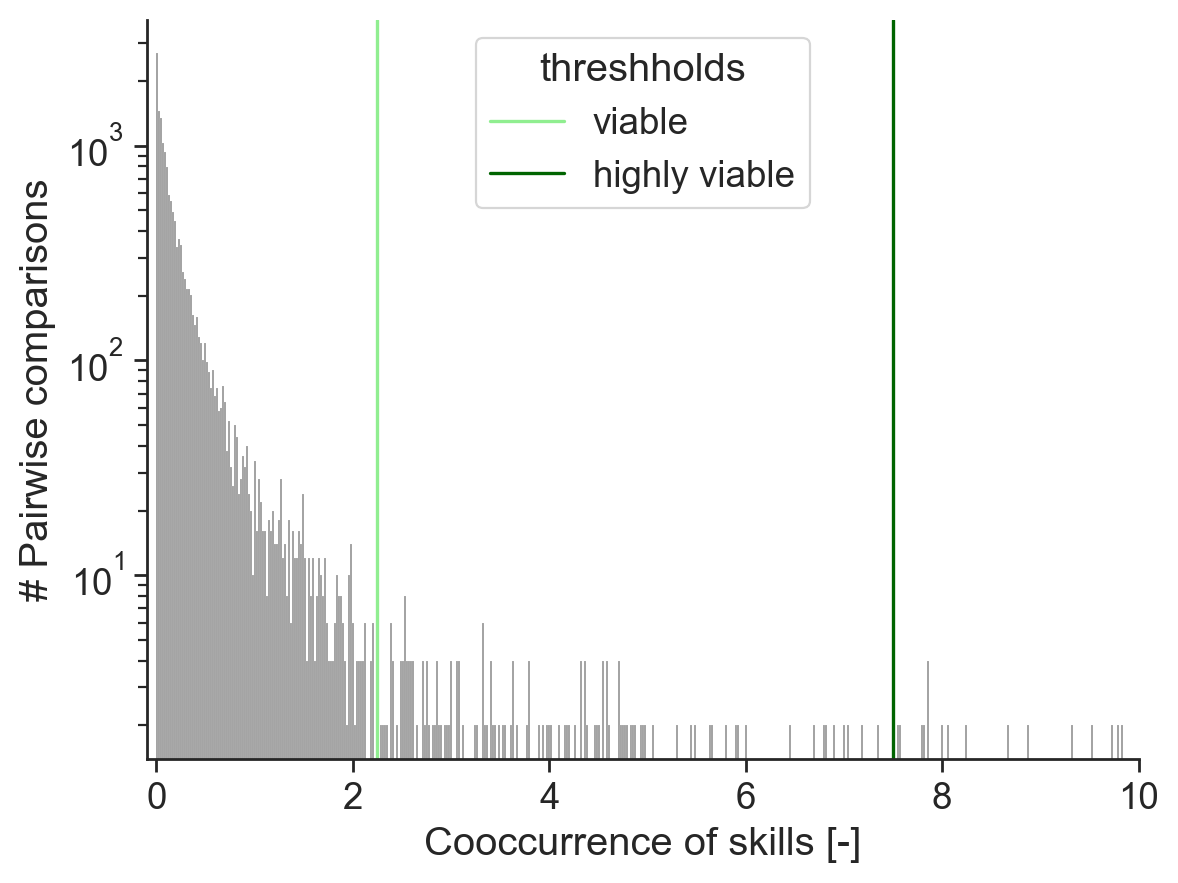

In [16]:
ax = sns.histplot(df_occ_sims.values.flatten(), color="grey", log_scale=(False, True))
ax.set_xlim(-0.1, 10)
ax.axvline(q_viable, color="lightgreen", label="viable")
ax.axvline(q_highly_viable, color="darkgreen", label="highly viable")
ax.set_ylabel("# Pairwise comparisons")
ax.set_xlabel("Cooccurrence of skills [-]")
plt.legend(loc="upper center", title="threshholds")
sns.despine()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "esco",
        "transition_threshold_calibration_percentile.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Plot occ sim matrix at ISCO 3- and 4-digit levels

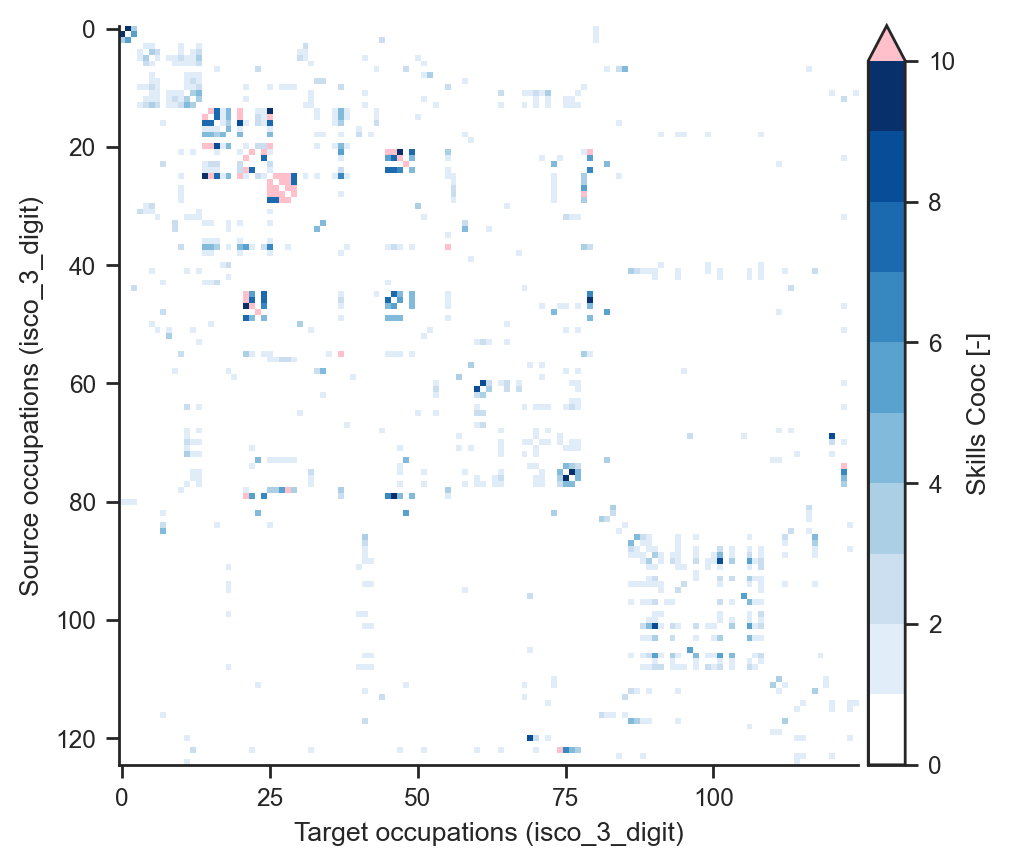

In [17]:
with sns.plotting_context("paper", font_scale=1.0):
    rp.plot_sim_matrix_at_level(level="isco_3_digit", vmax=10, mask_upper=False)

plt.savefig(
    os.path.join(useful_paths.figure_dir, "esco", "occ_sim_mat_isco3digit.png"),
    dpi=300,
    bbox_inches="tight",
)

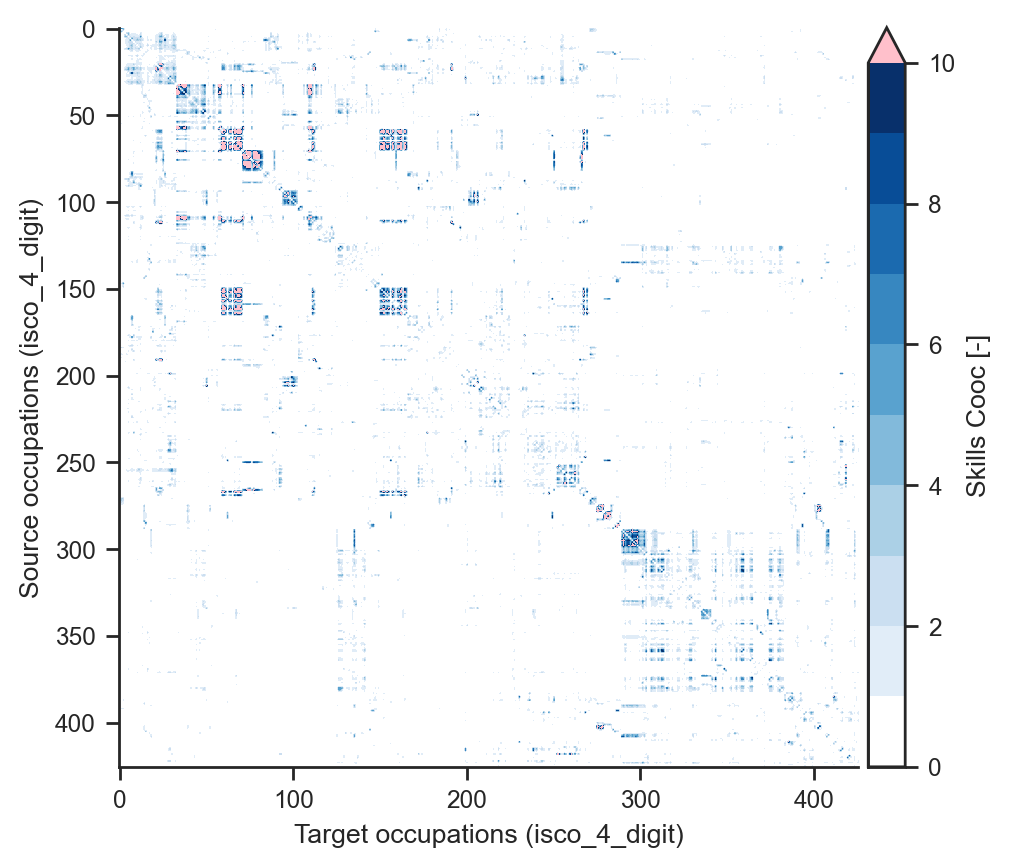

In [18]:
with sns.plotting_context("paper", font_scale=1.0):
    rp.plot_sim_matrix_at_level(level="isco_4_digit", vmax=10, mask_upper=False)

plt.savefig(
    os.path.join(useful_paths.figure_dir, "esco", "occ_sim_mat_isco4digit.png"),
    dpi=300,
    bbox_inches="tight",
)

##### Plot occupation similarity matrix classified viable/highly viable

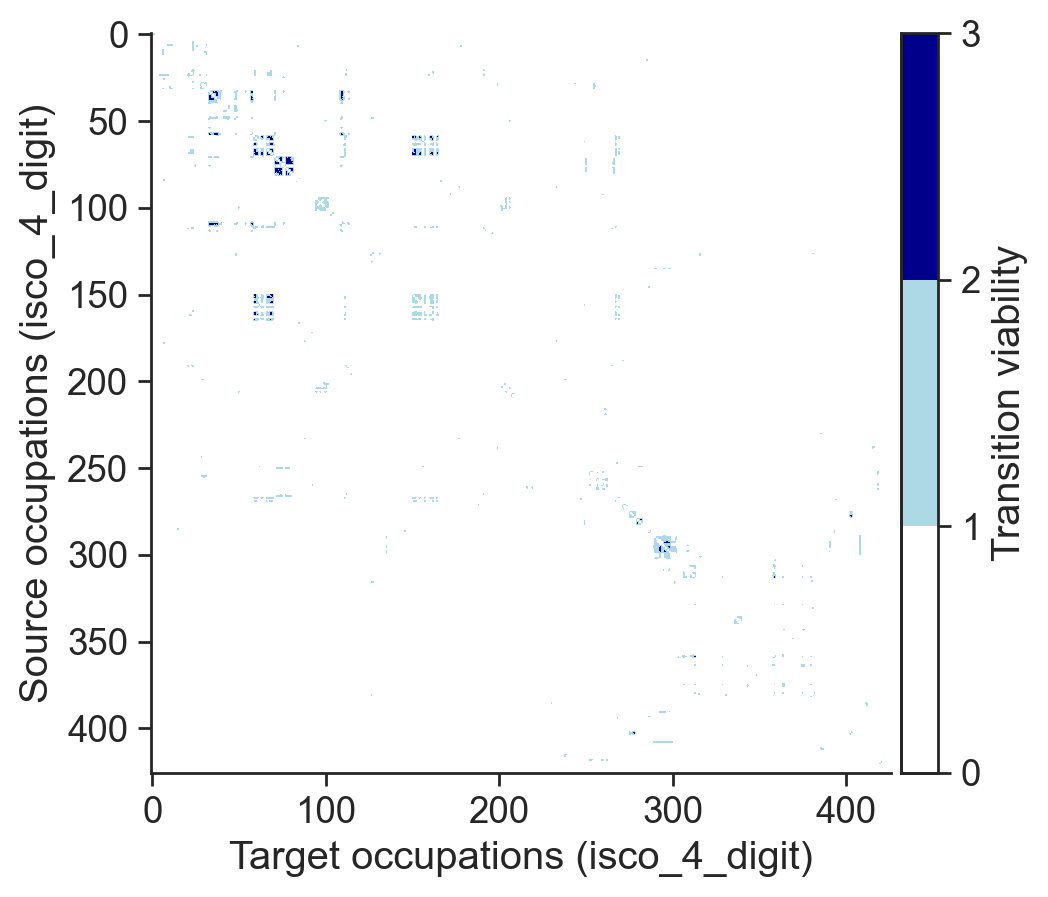

In [19]:
rp.plot_sim_matrix_at_level(level="isco_4_digit", classify=True, mask_upper=False)

plt.savefig(
    os.path.join(
        useful_paths.figure_dir, "esco", "occ_sim_mat_isco4digit_classified.png"
    ),
    dpi=300,
    bbox_inches="tight",
)

#### Transition analysis logic
Base the quantile on the respective quantiles of the viable/highly viable transition categories in the Kanders matrix
- Viable: 96th percentile
- Highly viable: 99th percentile

#### Manually check some transitions

In [20]:
rp.coal_occupations

{'Mining, manufacturing and construction supervisors': '312',
 'Mining and mineral processing plant operators': '811',
 'Manufacturing, mining, construction, and distribution managers': '132',
 'Mining and construction labourers': '931'}

In [21]:
occ = df_occs.loc[
    df_occs.preferredLabel == "Mining and mineral processing plant operators"
]
print(occ.preferredLabel)

transitions = find_closest(
    i=occ.index.values[0], similarity_matrix=similarity_matrix, df=df_occs
)

transitions.head(5)

100    Mining and mineral processing plant operators
Name: preferredLabel, dtype: object


,conceptUri,preferredLabel,code,similarity
90,http://data.europa.eu/esco/isco/C722,"Blacksmiths, toolmakers and related trades wor...",722,1.78
101,http://data.europa.eu/esco/isco/C812,Metal processing and finishing plant operators,812,1.72
106,http://data.europa.eu/esco/isco/C817,Wood processing and papermaking plant operators,817,1.58
103,http://data.europa.eu/esco/isco/C814,"Rubber, plastic and paper products machine ope...",814,1.41
89,http://data.europa.eu/esco/isco/C721,"Sheet and structural metal workers, moulders a...",721,1.08


##### Check the skills distribution at the ISCO 3-digit level

<AxesSubplot:ylabel='Frequency'>

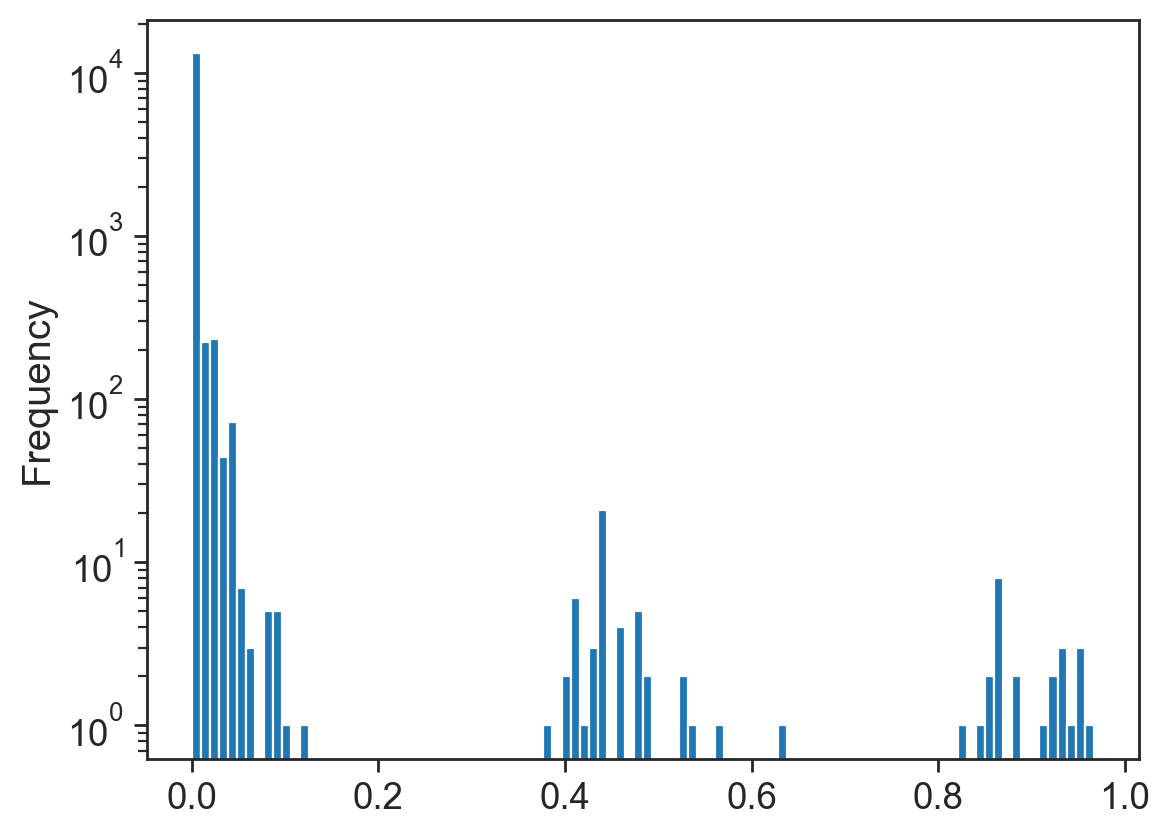

In [22]:
rp.occ_skills_mat_3d.iloc[25, :].plot.hist(bins=100, logy=True)

### Analyse number of viable transitions

In [23]:
countries = [
    "AT",
    "BE",
    "CH",
    # "CY",
    "CZ",
    "DE",
    "DK",
    # "EE",
    "ES",
    "FI",
    "FR",
    "GR",
    "HR",
    "HU",
    "IE",
    "IS",
    "IT",
    "LT",
    # "LU",
    "LV",
    "NL",
    "NO",
    "PT",
    "RO",
    "SE",
    "SK",
    "UK",
]

In [24]:
# modelling settings
scenarios = ["coal"]
upskilling_modes = [
    "optimal"
]  # , "random", "computer_literacy", "coreness_weighted", "coreness_percentile", "optimal"]
optimise = "wage"

# thresholds used for first set of results. Lower than the percentile-based thresholds.
transition_thresholds = 3.25, 6.5

# results storage
results_dir = os.path.join(useful_paths.figure_dir, "test")

##### Simulate (baseline, regional constraints, optimal reskilling)

##### Update upskilling analysis data

In [25]:
# TODO: move elsewhere!!!

# read
df_upskilling = pd.read_csv(os.path.join(useful_paths.data_interim, "upskilling_analysis", "upskilling_best_100_skills_per_isco3d_occupation.csv"), index_col=0)

# merge skill indices
df_upskilling_merged = pd.merge(df_upskilling, esco.skills.reset_index()[["index", "reuseLevel", "preferredLabel"]], how="left", left_on="skill_label", right_on="preferredLabel").drop(columns="preferredLabel").rename(columns={"index": "idx_skill"})

# merge occupation labels
df_upskilling_merged = pd.merge(df_upskilling_merged, esco.isco_groups[["preferredLabel", "code"]], how="left", left_on="ISCO3D_label", right_on="preferredLabel").drop(columns="preferredLabel").rename(columns={"code": "code_occ"})

# sort
df_upskilling_merged_sorted = df_upskilling_merged.sort_values(["code_occ", "new_viable_transitions", "coreness"], ascending=[True, False, False])

# save
df_upskilling_merged_sorted.to_csv(os.path.join(useful_paths.data_interim, "upskilling_analysis", "upskilling_best_100_skills_per_isco3d_occupation_merged.csv"))

In [26]:
df_upskilling_merged_sorted.head()

,ISCO3D_label,skill_label,coreness,new_viable_transitions,idx_skill,reuseLevel,code_occ
2500,Commissioned armed forces officers,manage budgets,0.82,1,1821,cross-sector,01
2503,Commissioned armed forces officers,adhere to organisational guidelines,0.49,1,9270,cross-sector,01
2506,Commissioned armed forces officers,apply health and safety standards,0.47,1,11961,cross-sector,01
2509,Commissioned armed forces officers,recruit employees,0.46,1,3992,cross-sector,01
2512,Commissioned armed forces officers,maintain relationship with customers,0.35,1,1854,sector-specific,01


In [27]:
%%time
#out_dir = "reskilling_simulation_v2_reg"
results = rp.simulate_regional(
    countries=["DE"],
    scenarios=["coal"],
    target_job_availability_coeff="COEFF_mean",
    transition_thresholds=transition_thresholds,  # (1.616368047779022, 6.500853535353546)
    reskilling="coreness_weighted",
    reskilling_journey_length=15,
    region_constraints=True,
    out_dir=os.path.join(useful_paths.figure_dir, results_dir),
    verbose=False,
)

Viability thresholds: 3.25 6.5
scenario: coal


100%|██████████| 37/37 [00:39<00:00,  1.08s/it]


CPU times: total: 3min 51s
Wall time: 41.2 s


In [28]:
results["coal"]["DE"]

AGE     COEFF  COEFF_share_brown_sl  \
COUNTRYW NUTS_ID NACE1D                                         
DE       DE11    B      55.75 11,798.00             10,870.14   
                 D      50.00 28,713.00              3,210.22   
         DE12    D      49.50 10,268.00                347.04   
         DE13    B      37.00  1,683.00                 56.61   
                 D      55.75  9,469.00                319.23   
...                       ...       ...                   ...   
         DEE0    D      54.00 12,631.00                426.62   
         DEF0    B      62.00  3,162.00                106.86   
                 D      32.00  2,703.00                 91.56   
         DEG0    B      44.00 21,250.00             17,723.68   
                 D      43.67  8,245.00                278.76   

                         COEFF_share_brown_slt  COEFF_share_green  \
COUNTRYW NUTS_ID NACE1D                                             
DE       DE11    B                    5,887.99               0.00   
                 D                    2,054.19           1,408.72   
         DE12    D                      269.14             382.50   
         DE13    B                       28.31               0.00   
                 D                      319.23             638.45   
...                                        ...                ...   
         DEE0    D                      383.84             682.09   
         DEF0    B                      106.86             213.71   
                 D                       45.78               0.00   
         DEG0    B                    9,715.22               0.00   
                 D                      241.60             408.89   

                         COEFF_share_neutral_sl  COEFF_share_neutral_slt  \
COUNTRYW NUTS_ID NACE1D                                                    
DE       DE11    B                       905.85                 5,887.99   
                 D                    24,000.18                25,156.21   
         DE12    D                     9,508.12                 9,586.01   
         DE13    B                     1,613.51                 1,641.82   
                 D                     8,459.47                 8,459.47   
...                                         ...                      ...   
         DEE0    D                    11,476.68                11,519.47   
         DEF0    B                     2,831.66                 2,831.66   
                 D                     2,609.44                 2,655.22   
         DEG0    B                     3,461.55                11,470.01   
                 D                     7,535.72                 7,572.87   

                          NOBS  transition_viable_step_0  \
COUNTRYW NUTS_ID NACE1D                                    
DE       DE11    B       68.00                      0.00   
                 D      170.00                      0.35   
         DE12    D       68.00                      1.00   
         DE13    B       17.00                      1.00   
                 D       68.00                      1.00   
...                        ...                       ...   
         DEE0    D       85.00                      1.00   
         DEF0    B       17.00                      1.00   
                 D       17.00                      1.00   
         DEG0    B      170.00                      0.01   
                 D       51.00                      1.00   

                         n_viable_transitions_step_0  ...  \
COUNTRYW NUTS_ID NACE1D                               ...   
DE       DE11    B                              0.00  ...   
                 D                              0.35  ...   
         DE12    D                              1.00  ...   
         DE13    B                              1.00  ...   
                 D                              1.00  ...   
...                                              ...  ...   
         DEE0    D      

In [ ]:
# Visualise results
rp.visualise_simulation_results_eu(
    simulation_results=results,
    transition_optimisation="wage",
    reskilling_version="reskilling_reg",
    step=15,
    vmax_wages=100,
    vmax_transitions=8,
    base_dir=os.path.join(useful_paths.figure_dir, results_dir),
    title_fontsize="small",
    cbar_fraction=0.025,
    show_plots=True,
    show_title=True
)

In [ ]:
assert 1 == 2

##### Simulate baseline

In [ ]:
%%time
simulation_results = rp.simulate(
    level="isco_3_digit",
    countries=countries,
    scenarios=["coal"],
    transition_optimisation=optimise,
    reskilling=None,
    mask_diagonal=True,
    transition_thresholds=transition_thresholds,
    out_dir=results_dir,
)

In [ ]:
rp.visualise_simulation_results_eu(
    simulation_results=simulation_results,
    transition_optimisation="wage",
    version="baseline",
    vmax_wages=100,
    vmax_transitions=8,
    base_dir=results_dir,
)

##### Create visualisation

#### Scenario 2b) Wage continuity + regional constraint

##### Regional distribution of unique occupations
Needed for regional reskilling constraint.

In Germany, over 90% of all unique 3-digit occupations have COEFF > 0 in each NUTS2 region

In [ ]:
countries = [
    "AT",
    "BE",
    "CH",
    # "CY",
    "CZ",
    "DE",
    "DK",
    # "EE",
    "ES",
    "FI",
    "FR",
    "GR",
    "HR",
    "HU",
    "IE",
    "IS",
    "IT",
    "LT",
    # "LU",
    # "LV",
    # "NL",
    "NO",
    "PT",
    "RO",
    "SE",
    "SK",
    "UK",
]

threshold = (1.616368047779022, 6.500853535353546)

##### Fraction based employment availability

##### Simulate (baseline)

In [ ]:
%%time
out_dir = "reskilling_simulation_v2"
baseline_results = rp.simulate_regional(
    countries=countries,
    scenarios=["coal"],
    target_job_availability_coeff="COEFF_mean",
    transition_thresholds=threshold,  # (1.616368047779022, 6.500853535353546)
    reskilling=None,
    region_constraints=False,
    out_dir=os.path.join(useful_paths.figure_dir, out_dir),
    verbose=False,
)

# Visualise results
rp.visualise_simulation_results_eu(
    simulation_results=baseline_results,
    transition_optimisation="wage",
    version="baseline",
    vmax_wages=100,
    vmax_transitions=8,
    base_dir=os.path.join(useful_paths.figure_dir, out_dir),
    show_plots=True,
    title_fontsize="small",
    cbar_fraction=0.025,
)

##### Simulate (baseline, regional constraints)

In [ ]:
%%time
out_dir = "reskilling_simulation_v2_reg"
baseline_results = rp.simulate_regional(
    countries=countries,
    scenarios=["coal"],
    target_job_availability_coeff="COEFF_mean",
    transition_thresholds=threshold,  # (1.616368047779022, 6.500853535353546)
    reskilling=None,
    region_constraints=True,
    out_dir=os.path.join(useful_paths.figure_dir, out_dir),
    verbose=False,
)

# Visualise results
rp.visualise_simulation_results_eu(
    simulation_results=baseline_results,
    transition_optimisation="wage",
    version="baseline_reg",
    vmax_wages=100,
    vmax_transitions=8,
    base_dir=os.path.join(useful_paths.figure_dir, out_dir),
    show_plots=True,
    title_fontsize="small",
    cbar_fraction=0.025,
)

##### Simulate (baseline, optimal reskilling)

In [ ]:
%%time
out_dir = "reskilling_simulation_v2"
baseline_results = rp.simulate_regional(
    countries=countries,
    scenarios=["coal"],
    target_job_availability_coeff="COEFF_mean",
    transition_thresholds=threshold,
    reskilling="optimal",
    region_constraints=False,
    out_dir=os.path.join(useful_paths.figure_dir, out_dir),
    verbose=False,
)

# Visualise results
rp.visualise_simulation_results_eu(
    simulation_results=baseline_results,
    transition_optimisation="wage",
    version="reskilling",
    vmax_wages=100,
    vmax_transitions=8,
    base_dir=os.path.join(useful_paths.figure_dir, out_dir),
    show_plots=True,
    title_fontsize="small",
    cbar_fraction=0.025,
)

##### Simulate (baseline, regional constraints, optimal reskilling)

In [ ]:
%%time
out_dir = "reskilling_simulation_v2_reg"
baseline_results = rp.simulate_regional(
    countries=countries,
    scenarios=["coal"],
    target_job_availability_coeff="COEFF_mean",
    transition_thresholds=threshold,  # (1.616368047779022, 6.500853535353546)
    reskilling="optimal",
    region_constraints=True,
    out_dir=os.path.join(useful_paths.figure_dir, out_dir),
    verbose=False,
)

# Visualise results
rp.visualise_simulation_results_eu(
    simulation_results=baseline_results,
    transition_optimisation="wage",
    version="reskilling_reg",
    vmax_wages=100,
    vmax_transitions=8,
    base_dir=os.path.join(useful_paths.figure_dir, out_dir),
    show_plots=True,
    title_fontsize="small",
    cbar_fraction=0.025,
)

##### Regional availability of jobs after transitions
- How many percent of available jobs were filled by transitioning workers?
- How many jobs remain (as a percentage of the original number)?